# Phase 4 — Model Comparison

[`walkthrough/phase4.md`](../walkthrough/phase4.md)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../dataset/features.csv")

CATEGORICALS = ["Occupation", "Area_Type", "Caste_Group", "Religion"]
DROP = ["IDHH", "WT", "Goal_Met", "Savings_Rate"] + [c for c in df.columns if c.endswith("_CLR")]
NUMERIC = [c for c in df.columns if c not in DROP + CATEGORICALS]

X = df[NUMERIC + CATEGORICALS]
y = df["Goal_Met"]


def preprocessor(scaler=RobustScaler()):
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", scaler)]), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICALS),
    ])


print(f"households: {len(df):,}   numeric: {len(NUMERIC)}   categorical: {len(CATEGORICALS)}")
print(f"Goal_Met rate: {y.mean():.4f}")

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, cross_val_predict, cross_validate,
                                     train_test_split)
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

CV = StratifiedKFold(5, shuffle=True, random_state=42)
SCORING = ["accuracy", "f1_macro", "roc_auc", "precision", "recall"]

# A held-out test set is split off now and touched only once, at the very end.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"train: {len(X_train):,}   test (held out until the final cell): {len(X_test):,}")

households: 41,518   numeric: 24   categorical: 4
Goal_Met rate: 0.3193


train: 33,214   test (held out until the final cell): 8,304


## Q1 — Which model families are appropriate, and Q2 — what validation strategy fits the class balance?

In [2]:
MODELS = {
    "Majority baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": make_pipeline(preprocessor(), LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Linear SVM": make_pipeline(preprocessor(), LinearSVC(class_weight="balanced", max_iter=5000, dual="auto")),
    "Decision Tree": make_pipeline(preprocessor(), DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42)),
    "Random Forest": make_pipeline(preprocessor(), RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1)),
    "HistGradientBoosting": make_pipeline(preprocessor(), HistGradientBoostingClassifier(random_state=42)),
    "XGBoost": make_pipeline(preprocessor(), XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=42, n_jobs=-1)),
}

rows = []
for name, model in MODELS.items():
    scoring = [s for s in SCORING if not (s == "roc_auc" and name == "Linear SVM")]
    res = cross_validate(model, X_train, y_train, cv=CV, scoring=scoring)
    row = {"model": name,
           "CV accuracy": res["test_accuracy"].mean(),
           "CV F1 (macro)": res["test_f1_macro"].mean(),
           "CV precision": res["test_precision"].mean(),
           "CV recall": res["test_recall"].mean(),
           "F1 sd": res["test_f1_macro"].std()}
    row["CV ROC-AUC"] = res["test_roc_auc"].mean() if "test_roc_auc" in res else np.nan
    rows.append(row)
    print(f"  done: {name}")

comparison = pd.DataFrame(rows).set_index("model").sort_values("CV F1 (macro)", ascending=False)
print()
print(comparison.round(4).to_string())

  done: Majority baseline


  done: Logistic Regression


  done: Linear SVM


  done: Decision Tree


  done: Random Forest


  done: HistGradientBoosting


  done: XGBoost

                      CV accuracy  CV F1 (macro)  CV precision  CV recall   F1 sd  CV ROC-AUC
model                                                                                        
XGBoost                    0.8614         0.8371        0.8064     0.7446  0.0018      0.9306
HistGradientBoosting       0.8606         0.8360        0.8065     0.7412  0.0021      0.9306
Random Forest              0.8512         0.8249        0.7914     0.7253  0.0032      0.9170
Logistic Regression        0.8343         0.8186        0.6984     0.8466  0.0037      0.9213
Linear SVM                 0.8332         0.8177        0.6961     0.8479  0.0039         NaN
Decision Tree              0.8067         0.7889        0.6614     0.8091  0.0052      0.8847
Majority baseline          0.6807         0.4050        0.0000     0.0000  0.0000      0.5000


## Q3 — Hyperparameter search: which parameters move performance most?

In [3]:
from sklearn.model_selection import RandomizedSearchCV

# Search is run on the two strongest families only. A wide search across all seven would
# cost far more compute for candidates the comparison above already ruled out.
search_space = {
    "xgbclassifier__max_depth": [4, 6, 8, 10],
    "xgbclassifier__learning_rate": [0.03, 0.08, 0.15],
    "xgbclassifier__n_estimators": [200, 400, 700],
    "xgbclassifier__subsample": [0.7, 0.9, 1.0],
    "xgbclassifier__min_child_weight": [1, 5, 20],
}
xgb_search = RandomizedSearchCV(
    make_pipeline(preprocessor(), XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)),
    search_space, n_iter=15, cv=CV, scoring="f1_macro", random_state=42, n_jobs=1,
)
xgb_search.fit(X_train, y_train)
print(f"XGBoost best macro-F1: {xgb_search.best_score_:.4f}")
print("best params:", {k.split("__")[1]: v for k, v in xgb_search.best_params_.items()})

cv_res = pd.DataFrame(xgb_search.cv_results_)
print("\nwhich parameter moves the score most (sd of mean score across each level):")
sens = {}
for p in search_space:
    sens[p.split("__")[1]] = cv_res.groupby(f"param_{p}")["mean_test_score"].mean().std()
print(pd.Series(sens).sort_values(ascending=False).round(5).to_string())

XGBoost best macro-F1: 0.8377
best params: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.15}

which parameter moves the score most (sd of mean score across each level):
learning_rate       0.00397
subsample           0.00090
n_estimators        0.00082
min_child_weight    0.00054
max_depth           0.00033


In [4]:
lr_space = {"logisticregression__C": [0.01, 0.1, 1.0, 10.0, 100.0]}
lr_search = RandomizedSearchCV(
    make_pipeline(preprocessor(), LogisticRegression(max_iter=3000, class_weight="balanced")),
    lr_space, n_iter=5, cv=CV, scoring="f1_macro", random_state=42, n_jobs=1,
)
lr_search.fit(X_train, y_train)
print(f"Logistic Regression best macro-F1: {lr_search.best_score_:.4f}  "
      f"(C={lr_search.best_params_['logisticregression__C']})")
print("\nsensitivity to C:")
print(pd.DataFrame(lr_search.cv_results_)
      .set_index("param_logisticregression__C")["mean_test_score"].sort_index().round(4).to_string())

Logistic Regression best macro-F1: 0.8190  (C=100.0)

sensitivity to C:
param_logisticregression__C
0.01      0.8159
0.10      0.8186
1.00      0.8186
10.00     0.8188
100.00    0.8190


## Q4 — Given the business framing, is precision or recall more important?

In [5]:
# Phase 0 (IHDS) framing: the model triages households for a savings-product nudge.
# The actionable class is "NOT on track" (Goal_Met = 0) - those are the households an
# intervention would target. Reported precision/recall above are for the positive class,
# so the at-risk view is computed explicitly here.
best = xgb_search.best_estimator_ if xgb_search.best_score_ >= lr_search.best_score_ else lr_search.best_estimator_
best_name = "XGBoost" if xgb_search.best_score_ >= lr_search.best_score_ else "Logistic Regression"
print(f"selected model: {best_name}\n")

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

oof = cross_val_predict(best, X_train, y_train, cv=CV)
print("Out-of-fold performance, both classes:")
print(classification_report(y_train, oof, target_names=["not on track", "on track"], digits=3))

proba = cross_val_predict(best, X_train, y_train, cv=CV, method="predict_proba")[:, 1]
at_risk_score = 1 - proba
prec, rec, thr = precision_recall_curve(1 - y_train, at_risk_score)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_i = f1.argmax()
print(f"\nAt-risk class (Goal_Met = 0), threshold tuned for F1:")
print(f"  threshold: {thr[best_i]:.3f}   precision: {prec[best_i]:.3f}   recall: {rec[best_i]:.3f}   F1: {f1[best_i]:.3f}")
for target_recall in [0.80, 0.90, 0.95]:
    i = np.argmin(np.abs(rec - target_recall))
    print(f"  to reach recall {target_recall:.0%}: precision falls to {prec[i]:.3f} "
          f"(threshold {thr[min(i, len(thr) - 1)]:.3f})")

selected model: XGBoost



Out-of-fold performance, both classes:
              precision    recall  f1-score   support

not on track      0.885     0.916     0.900     22609
    on track      0.807     0.746     0.775     10605

    accuracy                          0.862     33214
   macro avg      0.846     0.831     0.838     33214
weighted avg      0.860     0.862     0.860     33214




At-risk class (Goal_Met = 0), threshold tuned for F1:
  threshold: 0.440   precision: 0.873   recall: 0.933   F1: 0.902
  to reach recall 80%: precision falls to 0.941 (threshold 0.757)
  to reach recall 90%: precision falls to 0.896 (threshold 0.554)
  to reach recall 95%: precision falls to 0.856 (threshold 0.368)


## Final evaluation on the held-out test set

FINAL — XGBoost, single evaluation on 8,304 held-out households

              precision    recall  f1-score   support

not on track      0.887     0.913     0.900      5653
    on track      0.802     0.751     0.776      2651

    accuracy                          0.862      8304
   macro avg      0.845     0.832     0.838      8304
weighted avg      0.860     0.862     0.860      8304

Confusion matrix (rows = true):
              pred not on track  pred on track
not on track               5163            490
on track                    660           1991


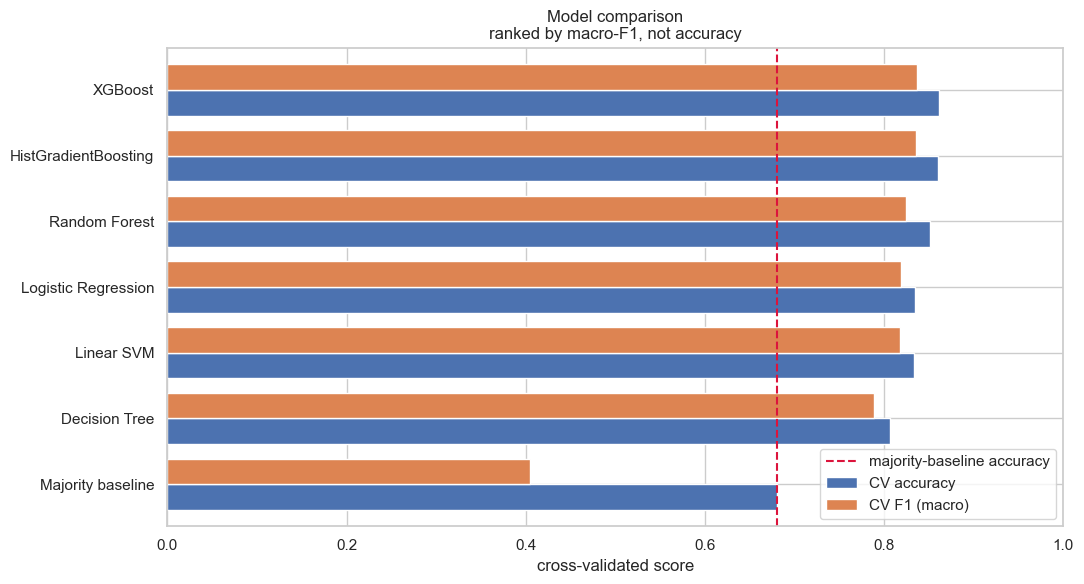


wrote ../results/model_comparison.csv and .png


In [6]:
best.fit(X_train, y_train)
test_pred = best.predict(X_test)

print(f"FINAL — {best_name}, single evaluation on {len(X_test):,} held-out households\n")
print(classification_report(y_test, test_pred, target_names=["not on track", "on track"], digits=3))
print("Confusion matrix (rows = true):")
print(pd.DataFrame(confusion_matrix(y_test, test_pred),
                   index=["not on track", "on track"],
                   columns=["pred not on track", "pred on track"]).to_string())

comparison.to_csv("../results/model_comparison.csv")

fig, ax = plt.subplots(figsize=(11, 6))
plot = comparison[["CV accuracy", "CV F1 (macro)"]].sort_values("CV F1 (macro)")
plot.plot(kind="barh", ax=ax, width=0.78)
ax.axvline(comparison.loc["Majority baseline", "CV accuracy"], color="crimson", ls="--",
           label="majority-baseline accuracy")
ax.set_xlim(0, 1.0)
ax.set_xlabel("cross-validated score")
ax.set_ylabel("")
ax.set_title("Model comparison\nranked by macro-F1, not accuracy")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nwrote ../results/model_comparison.csv and .png")